In [1]:
import sys
import os
# Tweak to ensure cwd is at root of repo
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [2]:
#from src.simulator.qccd_circuit import process_circuit

ds = [3,5,7]

for d in ds: 
    print(process_circuit(d,2,[1.0],100_000)) 
    #print(process_circuit_wise_arch(d,c,[1.0], 100_000)) 
    print('\n')


{'ElapsedTime': {'Forwarding': 0.004085000000000001}, 'Operations': {'Forwarding': 466}, 'MeanConcurrency': {'Forwarding': 6.781818181818182}, 'QubitOperations': {'Forwarding': 178}, 'LogicalErrorRates': {'Forwarding': [0.05494]}, 'PhysicalZErrorRates': {'Forwarding': [0.006711326100063682]}, 'PhysicalXErrorRates': {'Forwarding': [0.006163226932548814]}, 'Electrodes': {'Forwarding': 980}, 'DACs': {'Forwarding': 980}, 'Capacity': 2, 'Distance': 3}


{'ElapsedTime': {'Forwarding': 0.004085000000000001}, 'Operations': {'Forwarding': 1530}, 'MeanConcurrency': {'Forwarding': 20.115151515151513}, 'QubitOperations': {'Forwarding': 570}, 'LogicalErrorRates': {'Forwarding': [0.02023]}, 'PhysicalZErrorRates': {'Forwarding': [0.007041585573227546]}, 'PhysicalXErrorRates': {'Forwarding': [0.006418054713602888]}, 'Electrodes': {'Forwarding': 2800}, 'DACs': {'Forwarding': 2800}, 'Capacity': 2, 'Distance': 5}


{'ElapsedTime': {'Forwarding': 0.004080000000000001}, 'Operations': {'Forwarding': 3194}, 

In [3]:
from src.simulator.qccd_circuit import *
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import *

# testing the color code versions
ds = [9]
#erroring 
for d in ds:
    print(process_color_code_circuit(d,10,[1.0],100_000, (6,6,6)))
    print('\n')
    
"""
#ccobj = ColorCodeCircuit666(3,2)
qccd = QCCDCircuit.generate_color_code(5,2,(6,6,6))
print(f'before circuitString: {qccd}')
print(f'after circuitString: {qccd.circuitString()}')
#print(qccd.dataQubitsIdxs)
qccd._parseCircuitString(qccd.dataQubitsIdxs)
#print(qccd._measurementIons)
#print(qccd._dataIons)
#print(qccd._ionMapping)
#the measurement qubits aren't being picked up for some reason
"""

ValueError: Failed to decompose a complex error instruction into basic errors.
    The instruction (after shifting): error(0.000890686) D36 D40 D43 D61 D70 D73 L0
    The undecomposed X detectors: []
    The undecomposed Z detectors: [61, 70, 73]
    Decomposed piece: D36 D40 D43
    The undecomposed observable mask: L0
    Detector data:
        D36: coords=[13, 1, 1, 2] ColorBasis{.color=B, .basis=X}
        D40: coords=[16, 2, 1, 0] ColorBasis{.color=R, .basis=X}
        D43: coords=[13, 3, 1, 1] ColorBasis{.color=G, .basis=X}
        D61: coords=[10, 0, 2, 4] ColorBasis{.color=G, .basis=Z}
        D70: coords=[16, 2, 2, 3] ColorBasis{.color=R, .basis=Z}
        D73: coords=[13, 3, 2, 4] ColorBasis{.color=G, .basis=Z}
This problem can unfortunately be quite difficult to debug. Likely causes are:
    (1) The source circuit has detectors with invalid color/basis annotations.
    (2) The source circuit is producing errors too complex to decompose (e.g. more than 6 symptoms in one basis

In [ ]:
from src.color_code_utils.color_code_circuits.color_code_chrom_circuit_666 import *


ccobj = ColorCodeChromCircuit666(3,2)
qccd = QCCDCircuit.generate_color_code(5,2,(6,6,6))
print(f'before circuitString: {qccd}')
print(f'after circuitString: {qccd.circuitString()}')
#print(qccd.dataQubitsIdxs)
qccd._parseCircuitString(qccd.dataQubitsIdxs)
print(qccd._measurementIons)
print(qccd._dataIons)
print(qccd._ionMapping)
#the measurement qubits aren't being picked up for some reason

In [ ]:
import stim
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import *
with open("./preparation/testcirc.txt") as f:
    circstr = f.read()


cc = ColorCodeCircuit666(9,2)
#print(cc.get_circuit())
#print(f' qubits: {(cc.qubits)}')
#print(f' ancilla: {cc.ancilla}')
circuit = stim.Circuit(circstr)
# Run this in a notebook
circuit.diagram("detslice", filter_coords=['D36','D40','D43','D61', 'D70', 'D73'])
#filter_coords=['D36', 'D43'])

# If you know the failing detectors are [19, 37, 43]
matches = circuit.explain_detector_error_model_errors()

for match in matches:
    print(match)

In [ ]:
cc.draw_layout()

In [ ]:
qccd = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=2,
        distance=3,)
#print(f'before circuitString: {qccd}')
#print(f'after circuitString: {qccd.circuitString()}')
qccd._parseCircuitString()
#print(qccd._measurementIons)
#print(qccd._dataIons)
#print(qccd._ionMapping)

In [ ]:
from color_code_stim import ColorCode

colorcode = ColorCode(d=9,rounds=2,circuit_type="tri")
#print(str(colorcode.circuit))
c = stim.Circuit(colorcode.circuit.__str__())
c.diagram("detslice-svg")
#qccd = QCCDCircuit(str(colorcode.circuit))
#print(f'before circuitString: {qccd.flattened().decomposed()}')
#print(f'after circuitString: {qccd.circuitString()}')
#qccd._parseCircuitString()
#print(f"parsed: {qccd._parseCircuitString()}")
#print(qccd._measurementIons)
#print(qccd._dataIons)
#print(qccd._ionMapping)

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

file_path = r'.\data\surface_code_run.json'

with open(file_path, 'r') as f:
    raw_data = json.load(f)

records = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.
try:
    # Adjust these keys if your JSON nesting order is slightly different
    log_errs_dict = raw_data['LogicalErrorRates'][label]
    phys_x_dict = raw_data['PhysicalXErrorRates'][label]
    phys_z_dict = raw_data['PhysicalZErrorRates'][label]

# Iterate through the nested structure
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 100000  # Hardcoded based on your previous snippets
            })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
print(df)
print("Flattened Data:")
print(df.head())

# --- 2. Plotting ---
plt.figure(figsize=(10, 7))

# Get unique distances and capacities
distances = sorted(df['d'].unique())
# If you have multiple capacities, you might want to filter for just one, e.g.:
# df = df[df['capacity'] == 13] 

for d in distances:
    # Filter data for this distance
    subset = df[df['d'] == d].sort_values('p')
    
    # Calculate Standard Error
    subset['std_err'] = np.sqrt(subset['logical_error_rate'] * (1 - subset['logical_error_rate']) / subset['shots'])
    
    plt.errorbar(
        subset['p'], 
        subset['logical_error_rate'], 
        yerr=subset['std_err'],
        label=f'd={d}', 
        marker='o', 
        capsize=3,
        linestyle='--'
    )

# --- 3. Styling ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')
plt.xlim(0.0005,1e-1)
plt.title(f'Surface Code')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# Add a break-even line reference
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label="Break-even")

plt.show()

SyntaxError: expected 'except' or 'finally' block (2086963850.py, line 27)

     d  capacity         p  logical_error_rate   shots
0    3        12  0.018870            0.378871  100000
1    3        12  0.003774            0.117877  100000
2    3        12  0.001887            0.062675  100000
3    3        11  0.018870            0.378784  100000
4    3        11  0.003774            0.117847  100000
..  ..       ...       ...                 ...     ...
148  7       120  0.012722            0.349173  100000
149  7       120  0.006361            0.119420  100000
150  7        60  0.063612            0.500340  100000
151  7        60  0.012722            0.348873  100000
152  7        60  0.006361            0.119466  100000

[153 rows x 5 columns]
Flattened Data:
   d  capacity         p  logical_error_rate   shots
0  3        12  0.018870            0.378871  100000
1  3        12  0.003774            0.117877  100000
2  3        12  0.001887            0.062675  100000
3  3        11  0.018870            0.378784  100000
4  3        11  0.003774           

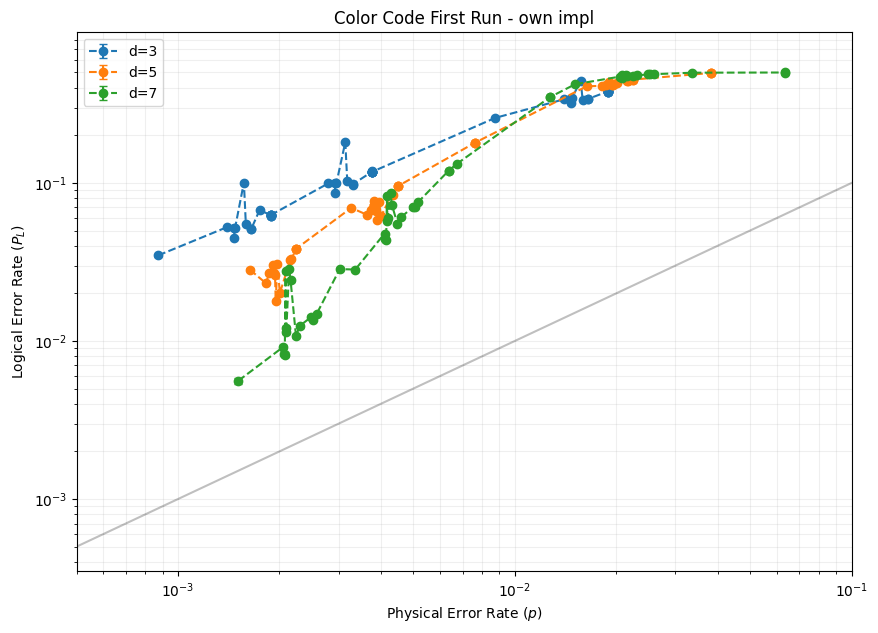

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

# --- 1. Load and Fix Data Structure ---
# Use raw string r'' to fix the SyntaxWarning about backslashes
file_path = r'.\data\color_code_first_run_data.json'

with open(file_path, 'r') as f:
    raw_data = json.load(f)

# The data is likely structured as: {Metric: {Algorithm: {Distance: {Capacity: [Values]}}}}
# We need to flatten this into a list of records.
records = []

# Assuming 'Forwarding' is your algorithm name based on your print output
algo_name = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.
try:
    # Adjust these keys if your JSON nesting order is slightly different
    log_errs_dict = raw_data['LogicalErrorRates'][algo_name]
    phys_x_dict = raw_data['PhysicalXErrorRates'][algo_name]
    phys_z_dict = raw_data['PhysicalZErrorRates'][algo_name]
except KeyError:
    # Fallback: maybe data is {Algorithm: {Metric: ...}}
    log_errs_dict = raw_data[algo_name]['LogicalErrorRates']
    phys_x_dict = raw_data[algo_name]['PhysicalXErrorRates']
    phys_z_dict = raw_data[algo_name]['PhysicalZErrorRates']

# Iterate through the nested structure
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 100000  # Hardcoded based on your previous snippets
            })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
print(df)
print("Flattened Data:")
print(df.head())

# --- 2. Plotting ---
plt.figure(figsize=(10, 7))

# Get unique distances and capacities
distances = sorted(df['d'].unique())
# If you have multiple capacities, you might want to filter for just one, e.g.:
# df = df[df['capacity'] == 13] 

for d in distances:
    # Filter data for this distance
    subset = df[df['d'] == d].sort_values('p')
    
    # Calculate Standard Error
    subset['std_err'] = np.sqrt(subset['logical_error_rate'] * (1 - subset['logical_error_rate']) / subset['shots'])
    
    plt.errorbar(
        subset['p'], 
        subset['logical_error_rate'], 
        yerr=subset['std_err'],
        label=f'd={d}', 
        marker='o', 
        capsize=3,
        linestyle='--'
    )

# --- 3. Styling ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')
plt.xlim(0.0005,1e-1)
plt.title(f'Color Code First Run - own impl')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# Add a break-even line reference
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label="Break-even")

plt.show()